# Sales Forecasting using ARIMA
This notebook performs time series analysis on monthly revenue data and forecasts future sales trends using the ARIMA model.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore") # Ignores ARIMA convergence warnings for clean output

# 1. Connect to PostgreSQL
# Credentials are loaded from the .env file in the project root
import os
from dotenv import load_dotenv
load_dotenv(os.path.join(os.path.dirname(os.getcwd()), '.env'))

db_user = os.getenv('POSTGRES_USER', 'postgres')
db_pass = os.getenv('POSTGRES_PASSWORD', 'password')
db_host = os.getenv('POSTGRES_HOST', 'localhost')
db_port = os.getenv('POSTGRES_PORT', '5432')
db_name = os.getenv('POSTGRES_DB', 'retail_dw')
engine = create_engine(f'postgresql://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}')

# 2. Extract Time Series Data (Monthly Revenue)
query = """
    SELECT 
        d.year,
        d.month,
        SUM(f.revenue) AS total_revenue
    FROM fact_sales f
    JOIN dim_date d ON f.date_id = d.date_id
    GROUP BY d.year, d.month
    ORDER BY d.year ASC, d.month ASC
"""
df_sales = pd.read_sql(query, engine)

# Create a proper DateTime index for Time Series analysis
df_sales['date'] = pd.to_datetime(df_sales[['year', 'month']].assign(DAY=1))
df_sales.set_index('date', inplace=True)
df_sales.drop(columns=['year', 'month'], inplace=True)

# 3. Fit the ARIMA Model
# Order (p, d, q) - Note: For real datasets, you would use ACF/PACF plots to tune these. 
# (1, 1, 1) is a standard starting point for baseline trend forecasting.
model = ARIMA(df_sales['total_revenue'], order=(1, 1, 1))
fitted_model = model.fit()

# 4. Forecast the Next 6 Months
forecast_steps = 6
forecast = fitted_model.forecast(steps=forecast_steps)

# Generate future dates for the forecast index
last_date = df_sales.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')
forecast.index = future_dates


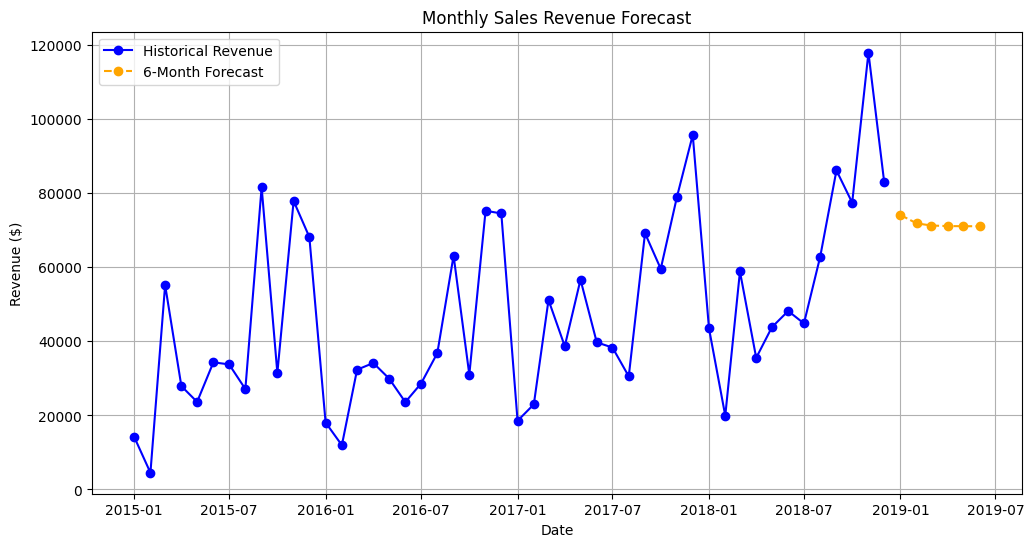

Predicted Revenue for Next 6 Months:
 2019-01-01    74121.340579
2019-02-01    71852.977843
2019-03-01    71275.421806
2019-04-01    71128.368175
2019-05-01    71090.926318
2019-06-01    71081.393112
Freq: MS, Name: predicted_mean, dtype: float64


In [6]:
# 5. Visualize Historical Data vs. Forecast
plt.figure(figsize=(12, 6))
plt.plot(df_sales.index, df_sales['total_revenue'], label='Historical Revenue', color='blue', marker='o')
plt.plot(forecast.index, forecast, label='6-Month Forecast', color='orange', linestyle='--', marker='o')

plt.title('Monthly Sales Revenue Forecast')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.legend()
plt.grid(True)
plt.show()

print("Predicted Revenue for Next 6 Months:\n", forecast)

## ACF/PACF Analysis for ARIMA Parameter Tuning
Autocorrelation and Partial Autocorrelation plots help determine optimal ARIMA (p, d, q) parameters.

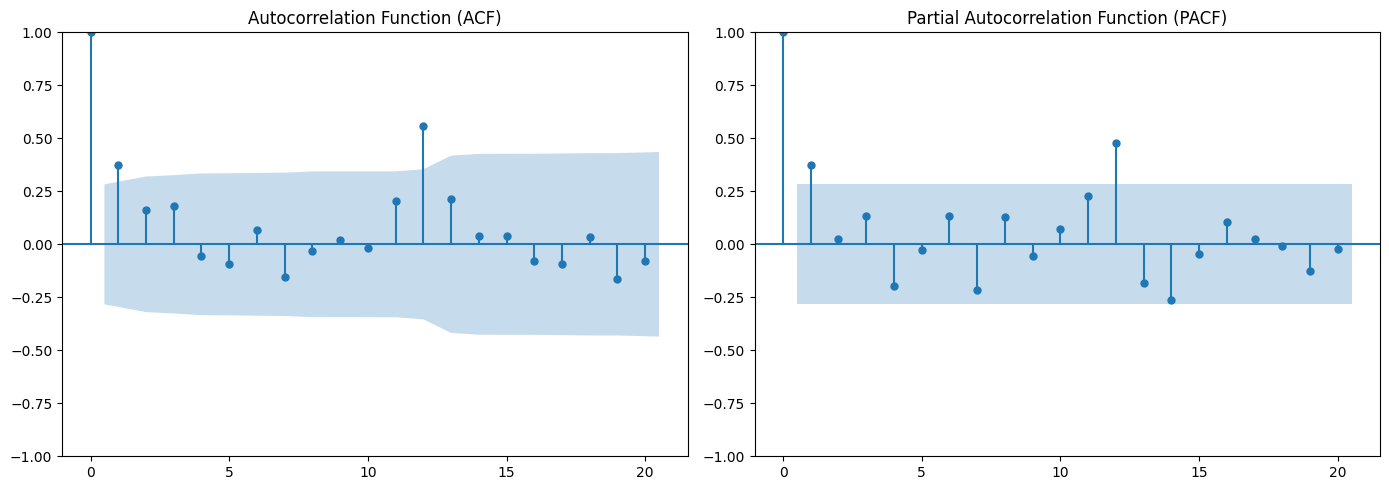

ACF/PACF Interpretation Guide:
- ACF shows correlation between the series and its lags.
- PACF shows correlation after removing effects of shorter lags.

To determine ARIMA(p, d, q) parameters:
- p (AR order): Look at PACF -- count significant lags before cutoff.
- d (Differencing): Usually 1 for non-stationary data with a trend.
- q (MA order): Look at ACF -- count significant lags before cutoff.

Current model uses ARIMA(1, 1, 1) as a baseline.
Adjust p and q based on the plots above for potentially better results.



In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# === ACF/PACF ANALYSIS FOR ARIMA PARAMETER TUNING ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df_sales['total_revenue'].dropna(), ax=axes[0], lags=20, title='Autocorrelation Function (ACF)')
plot_pacf(df_sales['total_revenue'].dropna(), ax=axes[1], lags=20, title='Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

print("""ACF/PACF Interpretation Guide:
================================
- ACF shows correlation between the series and its lags.
- PACF shows correlation after removing effects of shorter lags.

To determine ARIMA(p, d, q) parameters:
- p (AR order): Look at PACF -- count significant lags before cutoff.
- d (Differencing): Usually 1 for non-stationary data with a trend.
- q (MA order): Look at ACF -- count significant lags before cutoff.

Current model uses ARIMA(1, 1, 1) as a baseline.
Adjust p and q based on the plots above for potentially better results.
""")

## Model Evaluation Metrics
Evaluate the ARIMA model using RMSE, MAE, and MAPE to assess forecasting accuracy.

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# === MODEL EVALUATION METRICS ===

# In-sample evaluation (fitted values vs actuals)
fitted_values = fitted_model.fittedvalues
actuals = df_sales['total_revenue']

# Align series (fitted values may start from index 1 due to differencing)
common_index = actuals.index.intersection(fitted_values.index)
actual_aligned = actuals.loc[common_index]
fitted_aligned = fitted_values.loc[common_index]

# Calculate metrics
rmse = np.sqrt(mean_squared_error(actual_aligned, fitted_aligned))
mae = mean_absolute_error(actual_aligned, fitted_aligned)

# MAPE calculation (avoid division by zero)
non_zero_mask = actual_aligned != 0
mape = np.mean(np.abs((actual_aligned[non_zero_mask] - fitted_aligned[non_zero_mask]) / actual_aligned[non_zero_mask])) * 100

print("=" * 50)
print("ARIMA(1,1,1) MODEL EVALUATION METRICS")
print("=" * 50)
print(f"  RMSE  : ${rmse:,.2f}")
print(f"  MAE   : ${mae:,.2f}")
print(f"  MAPE  : {mape:.2f}%")
print()
print("Interpretation:")
print(f"  - RMSE (Root Mean Squared Error): Average prediction error is ~${rmse:,.0f}")
print(f"  - MAE (Mean Absolute Error): On average, predictions are off by ~${mae:,.0f}")
print(f"  - MAPE (Mean Absolute Percentage Error): {mape:.1f}% average deviation")
print()
if mape < 10:
    print("  Result: MAPE < 10% -- Good forecasting accuracy")
elif mape < 20:
    print("  Result: MAPE 10-20% -- Reasonable accuracy, consider tuning parameters")
else:
    print("  Result: MAPE > 20% -- Poor accuracy, model needs improvement")

# Print model summary
print("\n" + "=" * 50)
print("ARIMA MODEL SUMMARY")
print("=" * 50)
print(fitted_model.summary())

ARIMA(1,1,1) MODEL EVALUATION METRICS
  RMSE  : $23,112.29
  MAE   : $17,530.28
  MAPE  : 45.36%

Interpretation:
  - RMSE (Root Mean Squared Error): Average prediction error is ~$23,112
  - MAE (Mean Absolute Error): On average, predictions are off by ~$17,530
  - MAPE (Mean Absolute Percentage Error): 45.4% average deviation

  Result: MAPE > 20% -- Poor accuracy, model needs improvement

ARIMA MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:          total_revenue   No. Observations:                   48
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -539.293
Date:                Sat, 25 Apr 2026   AIC                           1084.585
Time:                        14:06:49   BIC                           1090.136
Sample:                    01-01-2015   HQIC                          1086.674
                         - 12-01-2018                                         
Covariance Type:                 